In [191]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [192]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)



In [193]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at all
teststar = df.sample(1)

df_test = df.sample(10000)

# Load a fake cluster

In [194]:
cluster = np.load('./fake-cluster-observations.npy', allow_pickle = True).item()
num_stars = len(cluster['FeH'])

In [376]:
def numpyro_beta_model(uncs, obs = model_outputs.obs_dict):

    mu_zini_centered = numpyro.sample('mu_zini_centered', dist.Beta(2, 10))

    mu_zini = numpyro.deterministic('mu_zini', 0.013 + 0.005*mu_zini_centered) #think loc should be LHS, scale should be the total width 
    
    
    std_zini_centered = numpyro.sample('std_zini_centered', dist.Beta(2, 10))

    std_zini = numpyro.deterministic('std_zini', 0.00001 + 0.01*std_zini_centered)


    mu_alphaMLT_centered = numpyro.sample('mu_alphaMLT_centered', dist.Beta(2, 10))

    mu_alphaMLT = numpyro.deterministic('mu_alphaMLT', 1.8 + 0.3*mu_alphaMLT_centered)
    

    std_alphaMLT_centered = numpyro.sample('std_alphaMLT_centered', dist.Beta(2, 10))

    std_alphaMLT = numpyro.deterministic('std_alphaMLT', 0.01 + 0.3*std_alphaMLT_centered)

    
    mu_age_centered = numpyro.sample('mu_age_centered', dist.Beta(2, 10))

    mu_age = numpyro.deterministic('mu_age', 9000 + 7000*mu_age_centered)


    std_age_centered = numpyro.sample('std_age_centered', dist.Beta(2, 10))

    std_age = numpyro.deterministic('std_age', 10 + 1000*std_age_centered)

    with numpyro.plate("star", num_stars):


            massini_centered = numpyro.sample('massini_centered', dist.Beta(2, 10))

            massini = numpyro.deterministic('massini', 0.75 + 1.3*massini_centered) #make beta

            zini = numpyro.sample('zini', dist.Normal(mu_zini, std_zini))

            yini_centered = numpyro.sample('yini_centered', dist.Beta(2, 10))

            yini = numpyro.deterministic('yini', 0.22 + 0.2*yini_centered) #make beta
    
            alphaMLT = numpyro.sample('alphaMLT', dist.Normal(mu_alphaMLT, std_alphaMLT))

            age = numpyro.sample('age', dist.Normal(mu_age,std_age)) #dunno how to solve this one

            eta_centered = numpyro.sample('eta_centered', dist.Beta(2, 10))

            eta = numpyro.deterministic('eta',0.05 + 0.15*eta_centered) #beta

            alphaFe = numpyro.sample('alphaFe', dist.Normal(0.1, 0.1)) #beta

            params_norm = jnp.stack([massini, zini, yini, alphaMLT, age, eta, alphaFe], axis = -1)

            pred_norm = model_outputs(params_norm)

            LPhot_out = numpyro.deterministic("LPhot_out", 10**pred_norm[:, 1])

    FeH = numpyro.sample("FeH", dist.Normal(pred_norm[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.Normal(LPhot_out, uncs['LPhot']), obs=obs['LPhot'])

    Teff = numpyro.sample("Teff", dist.Normal(pred_norm[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(pred_norm[:, 3], uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(pred_norm[:, 4], uncs['dnuSer']), obs=obs['dnuSer'])

In [377]:
np.min(df_test['yini'])

np.float64(0.220015869)

In [378]:
reparam_model = reparam(numpyro_beta_model, config={"alphaMLT": LocScaleReparam(0), 
                                                    'zini': LocScaleReparam(0), 'alphaFe': LocScaleReparam(0), \
                                                      'age': LocScaleReparam(0), 'eta':LocScaleReparam(0), 'alphaFe':LocScaleReparam(0)})

# Prior Predictive Test

In [379]:
phys_unc = {'Teff':150, 'LPhot':4, 'numax': 10/3090, 'dnuSer':1/135, 'FeH':0.2}
#uncert = jnp.array([phys_unc[i] for i in outputs])*jnp.ones_like(jnp.array(df_obs[outputs]))

In [380]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

prior_predictive = Predictive(reparam_model, num_samples=1000,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )

#y = prior.pop("y")
#for i, key in enumerate(model_outputs.outputs):
#    prior[key] = y[..., i]
coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

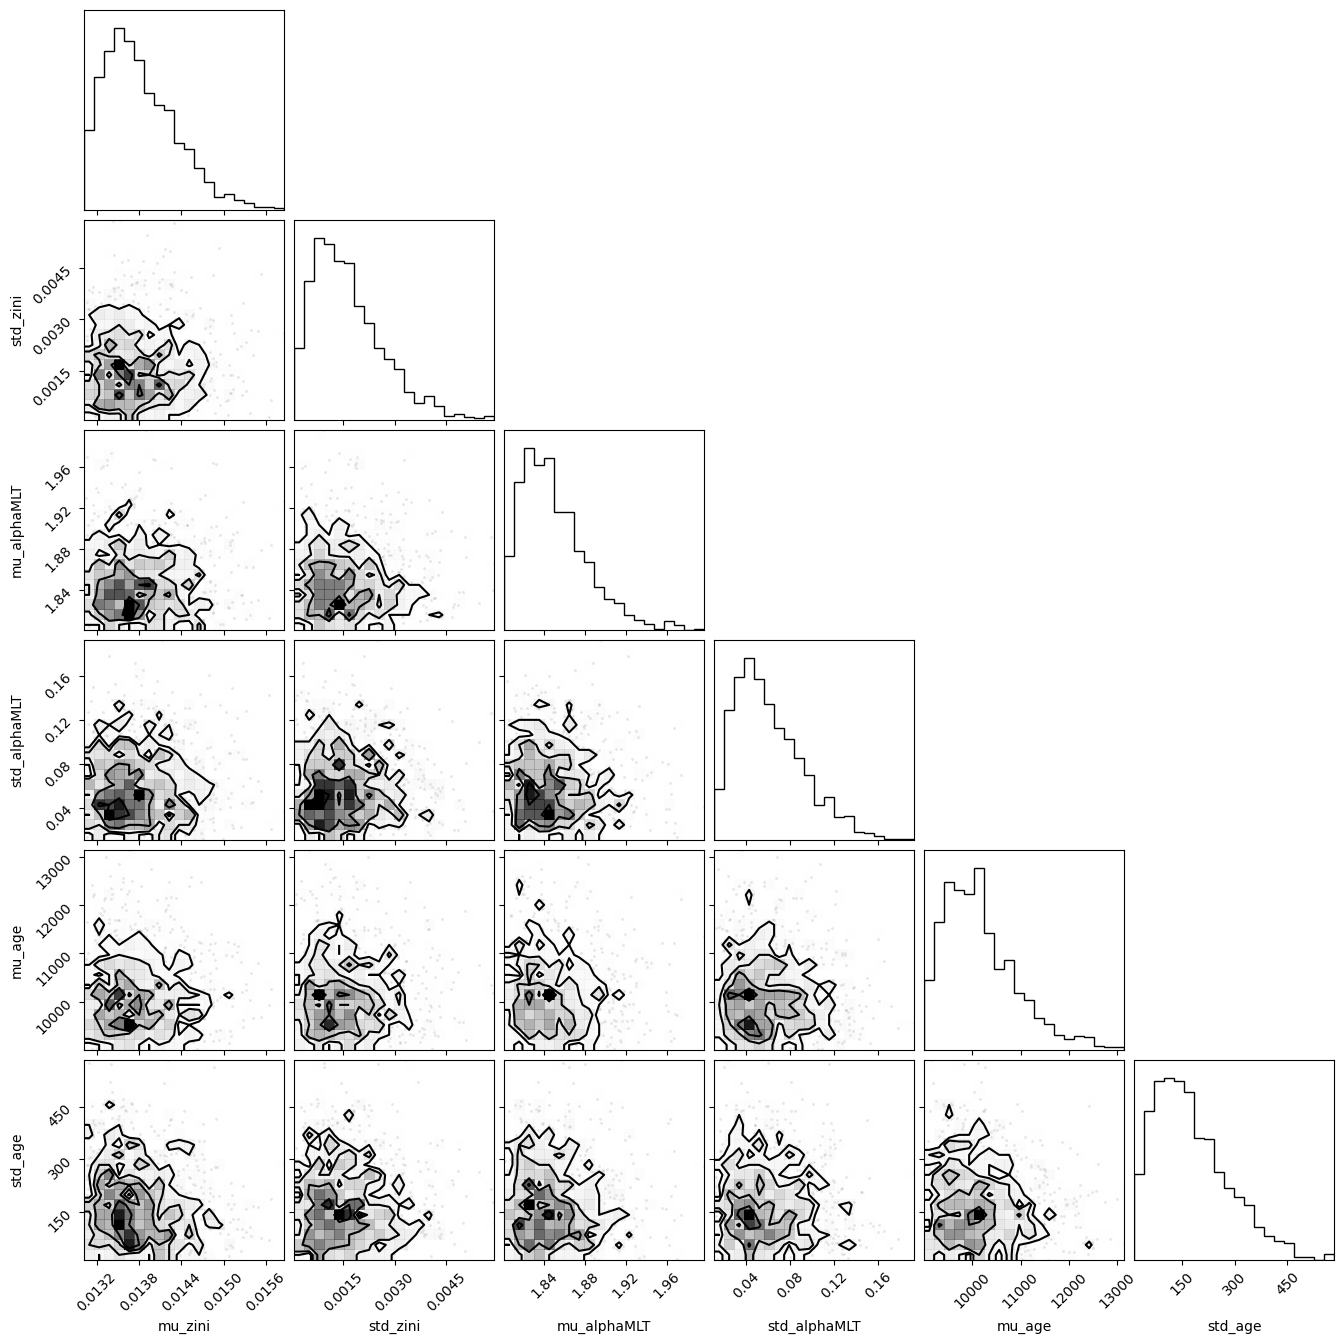

In [381]:
fig = corner.corner(data, group="prior", var_names=['mu_zini', 'std_zini', 'mu_alphaMLT','std_alphaMLT', 'mu_age', 'std_age'], )

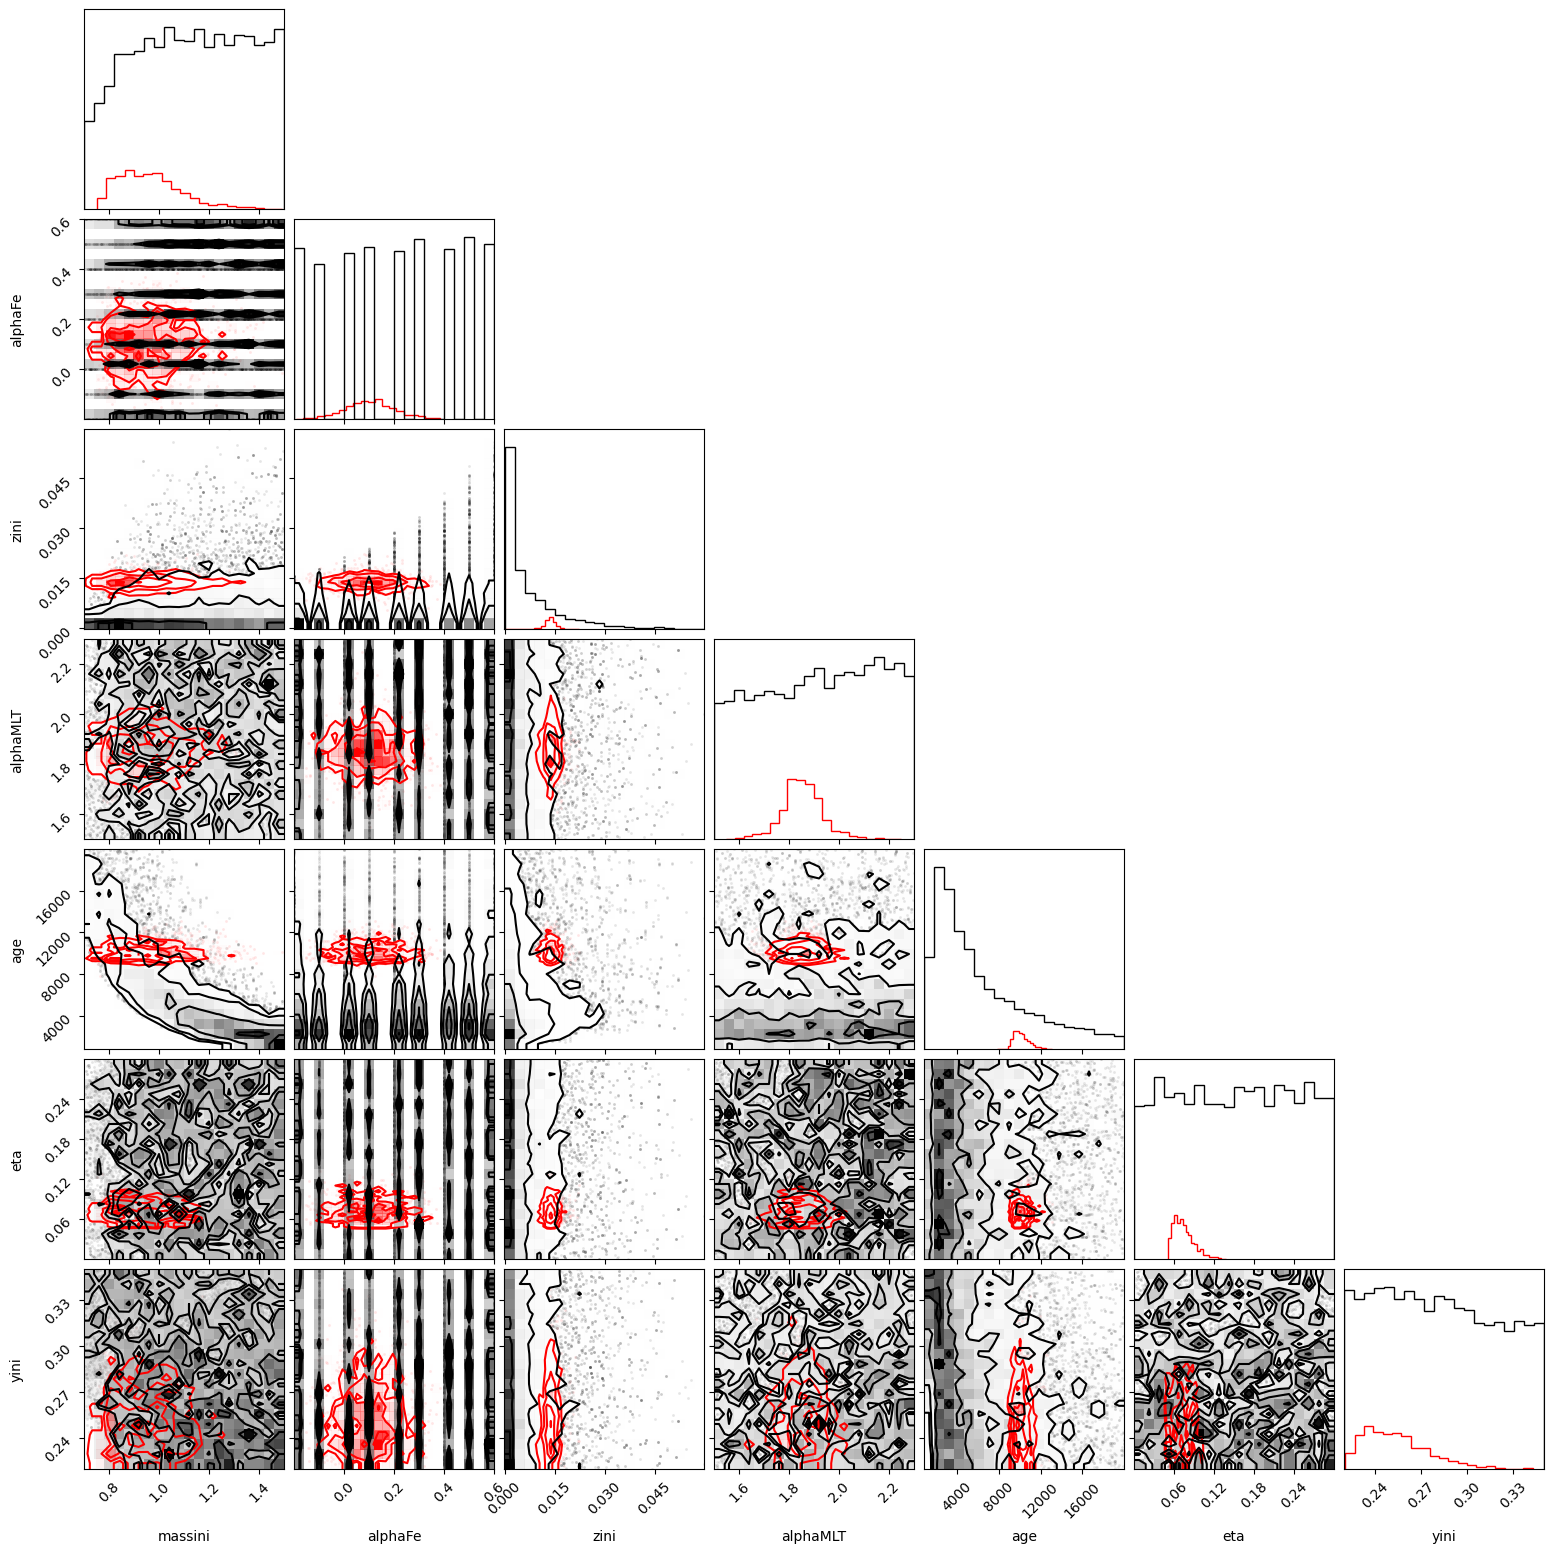

In [382]:
fig = corner.corner(data, group="prior", var_names=['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini'],color = 'red', coords = {'star': 0})

corner.corner(df_test[['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini']], fig = fig, zorder = 0, alpha = 0.5)
plt.show()

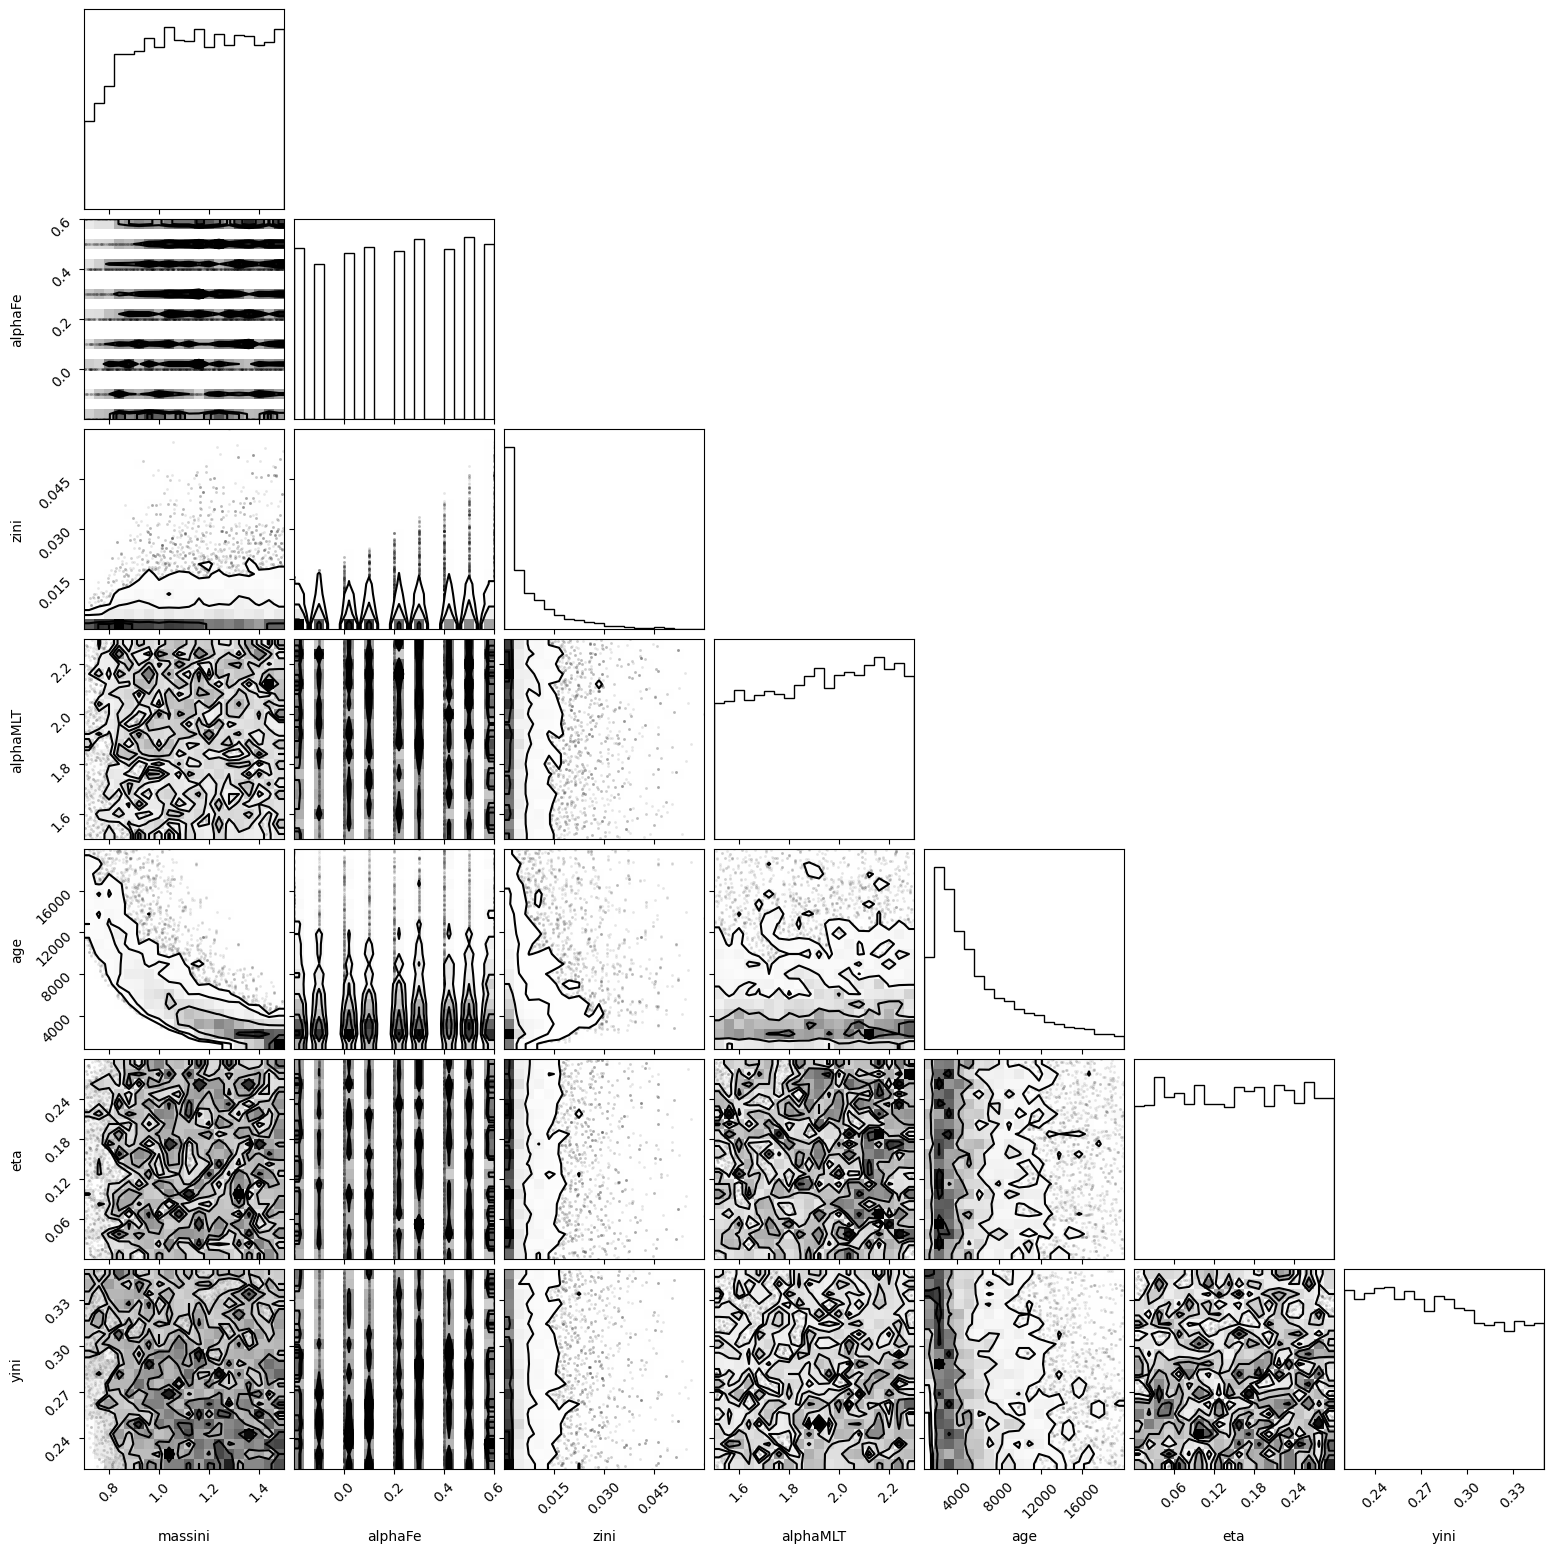

In [383]:
corner.corner(df_test[['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini']],zorder = 0, alpha = 0.5)
plt.show()

And now for the observables;

# Now to Fit

In [384]:
num_warmup, num_samples = 100, 100

num_chains = 2

sampler = NUTS(reparam_model, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

/tmp/ipykernel_3819262/2210578553.py:7: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)


In [385]:
mcmc.run(jax.random.PRNGKey(0),  uncs=phys_unc, obs=cluster)

mcmc.print_summary()

sample: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:44<00:00,  4.54it/s, 1023 steps of size 6.41e-12. acc. prob=0.74]


                             mean       std    median      5.0%     95.0%     n_eff     r_hat
      age_decentered[0]      0.14      0.05      0.14      0.09      0.19      1.01 2626319.00
      age_decentered[1]      0.21      0.07      0.21      0.14      0.27      1.01 1785074.38
      age_decentered[2]      0.03      0.15      0.03     -0.12      0.17      1.01 3724538.75
      age_decentered[3]      0.04      0.01      0.04      0.04      0.05       nan 1391147.00
      age_decentered[4]      0.15      0.00      0.15      0.15      0.15      1.01  77741.91
      age_decentered[5]      0.03      0.23      0.03     -0.20      0.26      1.01 5042987.00
      age_decentered[6]      0.12      0.26      0.12     -0.14      0.38      1.01 3931133.50
      age_decentered[7]      0.18      0.08      0.18      0.11      0.26      1.01 815643.38
      age_decentered[8]      0.18      0.14      0.18      0.04      0.33      1.01 2514930.50
      age_decentered[9]     -0.21      0.40     -0.2

Now we do a posterior predictive check to make sure everything makes sense

Plotting with arviz

In [186]:
posterior = mcmc.get_samples(group_by_chain=True)
sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))
posterior_predictive = Predictive(numpyro_model, posterior_samples=posterior, parallel=True, return_sites=["y"], batch_ndims=2)
#y = posterior_predictive(key,  obs=None, \
#                         uncs=uncert, )["y"]

#for i, key in enumerate(model_outputs.outputs):
#    posterior[key] = y[..., i]

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)
data

Inference data with groups:
	> posterior
	> sample_stats
	> prior

array([[<Axes: title={'center': 'mu_zini'}>,
        <Axes: title={'center': 'mu_zini'}>],
       [<Axes: title={'center': 'mu_alphaMLT'}>,
        <Axes: title={'center': 'mu_alphaMLT'}>],
       [<Axes: title={'center': 'mu_age'}>,
        <Axes: title={'center': 'mu_age'}>]], dtype=object)

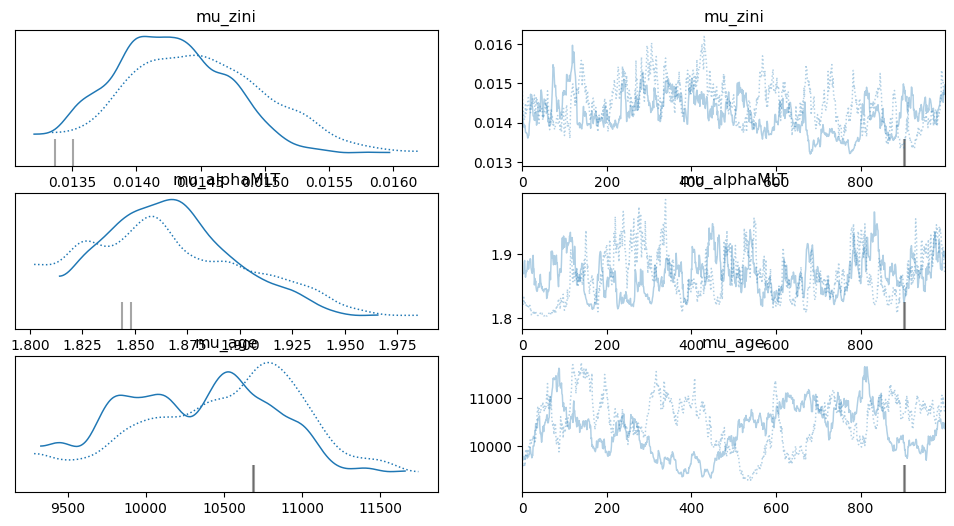

In [187]:
stat_funcs = {
    "q_16": lambda x: np.quantile(x, .16),
    "q_50": lambda x: np.quantile(x, .5),
    "q_84": lambda x: np.quantile(x, .84),
}

az.summary(data, fmt="xarray", stat_funcs=stat_funcs)
az.plot_trace(data, var_names=['mu_zini', 'mu_alphaMLT', 'mu_age'])

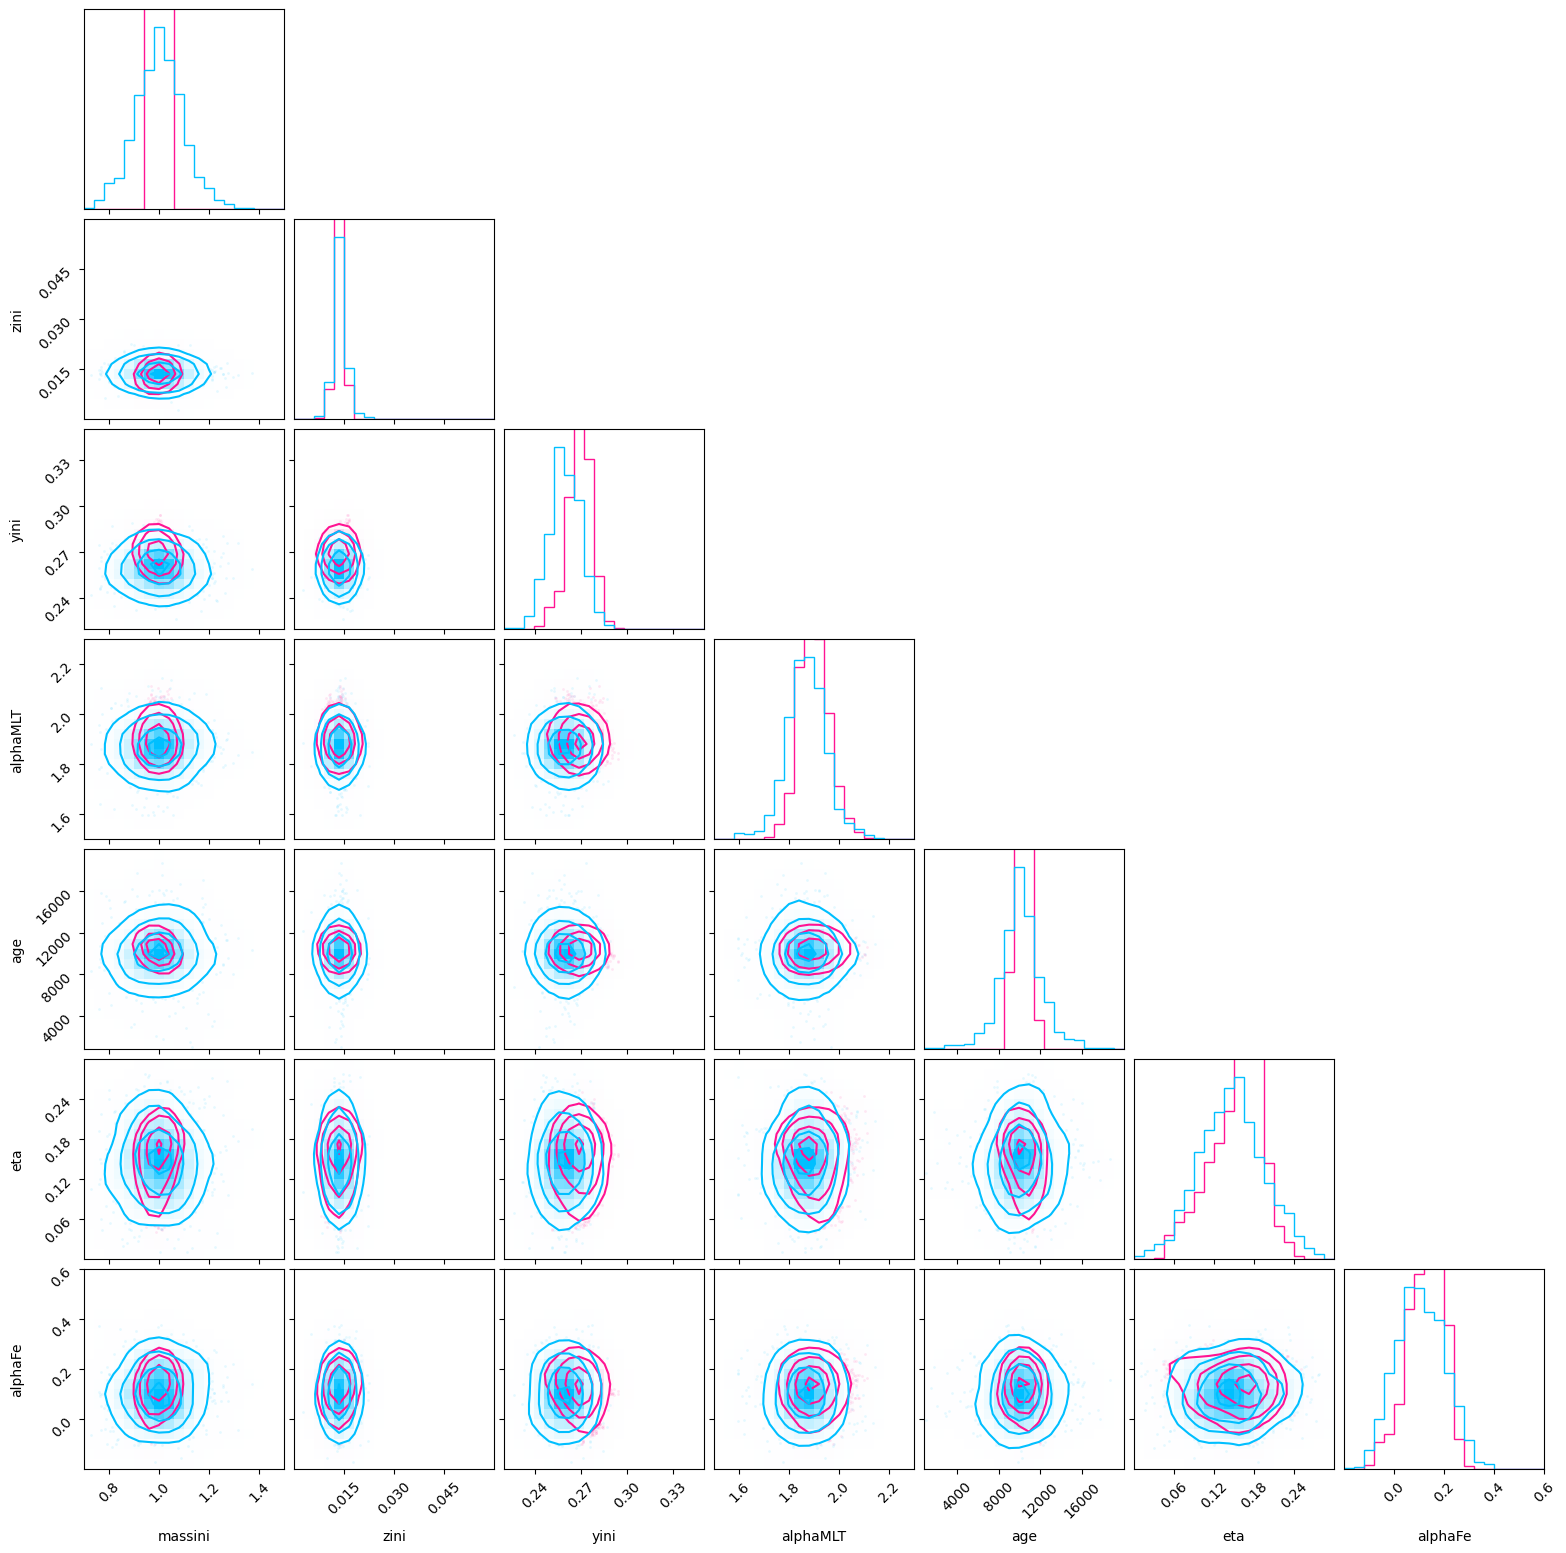

In [190]:
ranges = [(np.min(df_test[i].values), np.max(df_test[i].values)) for i in model_outputs.inputs]
#truths_inputs = [cluster[i].values[0] for i in model_outputs.inputs]
fig = corner.corner(data, group="posterior", var_names = model_outputs.inputs, coords = {'star':9}, color = 'deeppink', range = ranges, zorder = 1, weights = np.ones(2*num_samples)/(2*num_samples), smooth = True, plot_datapoints = True)
#corner.corner(df_test[model_outputs.inputs],zorder = 0, alpha = 0.5, fig = fig)
corner.corner(data, group="prior", var_names=model_outputs.inputs, \
                     coords = {'star':0}, fig = fig, range = ranges, zorder = -100, smooth = True, weights = np.ones(1000)/(1000), color = 'deepskyblue')
#fig.savefig(f'../figs/hierarchical-test-nstars-{int(num_stars)}-inputs.png', bbox_inches = 'tight', dpi = 150)
plt.show()

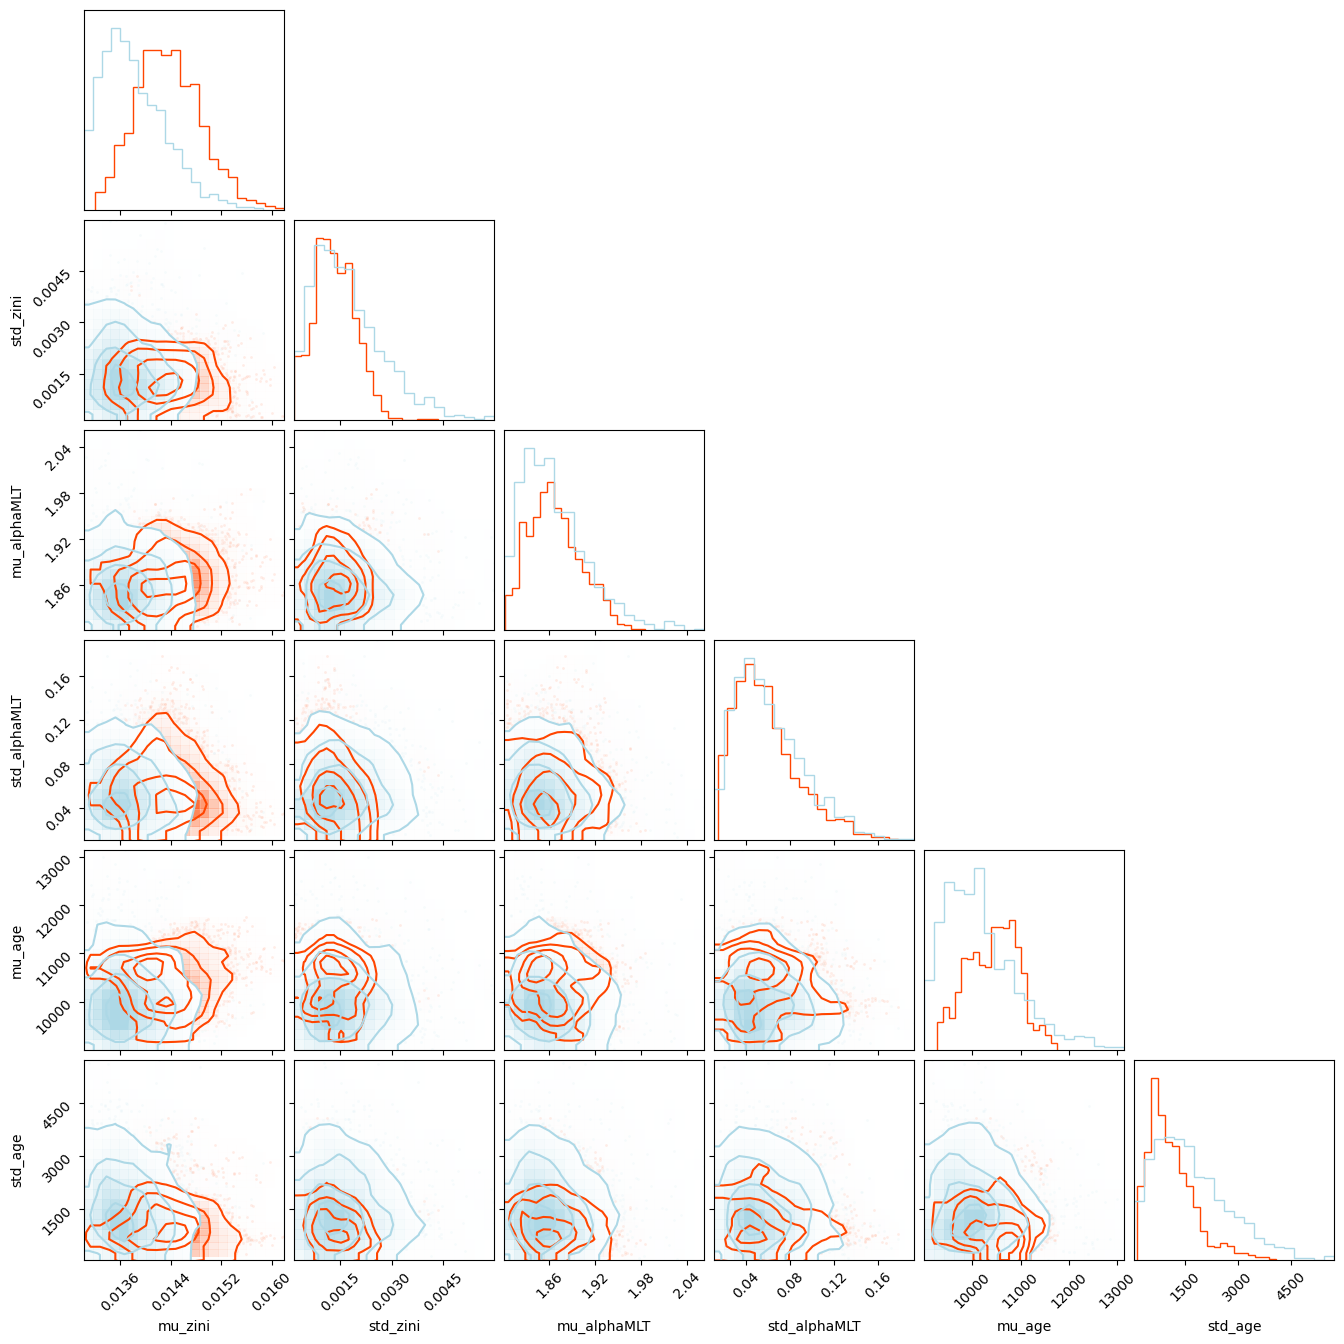

In [189]:

fig = corner.corner(data, group="posterior", var_names =hierarchical_params,  zorder = 1, weights = np.ones(2*num_samples)/(2*num_samples), \
                    color= 'orangered', smooth = True)
corner.corner(data, group="prior", var_names=hierarchical_params, \
                      fig = fig,  weights = np.ones(1000)/(1000), \
                      smooth = True, color = 'lightblue', truth_color = 'black')
fig.savefig(f'../figs/hierarchical-test-nstars-{int(num_stars)}-hierarchical-params.png', bbox_inches = 'tight', dpi = 150)
plt.show()

In [23]:
0.014 - 0.001

0.013000000000000001